<a href="https://colab.research.google.com/github/SathyaPrakashD/ml-pipeline-fundamentals/blob/main/12_heart_disease_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ❤️ Heart Disease Classification

A complete machine learning pipeline to predict the **presence or absence of heart disease** using the [Heart Statlog dataset](https://www.openml.org/d/53) from OpenML.

---

## Overview

Heart disease is one of the leading causes of death worldwide. Early and accurate detection can significantly improve patient outcomes. In this notebook, we build and evaluate multiple classification models to predict whether a patient has heart disease, based on clinical features such as age, chest pain type, blood pressure, cholesterol, and more.

**Dataset:** UCI Heart Disease (Heart Statlog) — 270 patients, 13 features  
**Task:** Binary classification — *absent* (no heart disease) vs *present* (heart disease)  
**Models Used:** DummyClassifier · RandomForestClassifier · LogisticRegression

---

## Table of Contents

1. [Load & Inspect Data](#section1)
2. [Exploratory Data Analysis (EDA)](#section2)
3. [Model Building](#section3)
4. [Model Comparison](#section4)
5. [Final Evaluation & Feature Importance](#section5)

## 1. Load & Inspect Data

In this section, we load the **Heart Statlog** dataset from OpenML using scikit-learn's `fetch_openml` utility. The dataset contains clinical measurements from **270 patients**, along with a binary target indicating whether heart disease is *absent* or *present*.

### Dataset Features

| Feature | Description |
|---|---|
| `age` | Age of the patient (years) |
| `sex` | Sex (1 = male, 0 = female) |
| `chest` | Chest pain type (1–4) |
| `resting_blood_pressure` | Resting blood pressure (mm Hg) |
| `serum_cholestoral` | Serum cholesterol (mg/dl) |
| `fasting_blood_sugar` | Fasting blood sugar > 120 mg/dl (1 = true, 0 = false) |
| `resting_electrocardiographic_results` | Resting ECG results (0–2) |
| `maximum_heart_rate_achieved` | Maximum heart rate achieved |
| `exercise_induced_angina` | Exercise-induced angina (1 = yes, 0 = no) |
| `oldpeak` | ST depression induced by exercise relative to rest |
| `slope` | Slope of the peak exercise ST segment (1–3) |
| `number_of_major_vessels` | Number of major vessels colored by fluoroscopy (0–3) |
| `thal` | Thalassemia (3 = normal, 6 = fixed defect, 7 = reversible defect) |
| `target` | Diagnosis (absent = no disease, present = disease) |

In [ ]:
# ============================================================
# CHECKPOINT 1 — Load & Inspect Data
# ============================================================


from typing import dataclass_transform
from sklearn.datasets import fetch_openml
import pandas as pd

# Step 1 — Load dataset
data = fetch_openml(name='heart-statlog', version=1, as_frame=True)

# Step 2 — Create DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Step 3 — Add target
df['target'] = data.target

print("Shape:", df.shape)
print("Classes:", df['target'].value_counts())
print("\nFirst 5 rows:")
print(df.head())

Shape: (270, 14)
Classes: target
absent     150
present    120
Name: count, dtype: int64

First 5 rows:
   age  sex  chest  resting_blood_pressure  serum_cholestoral  \
0   70    1      4                     130                322   
1   67    0      3                     115                564   
2   57    1      2                     124                261   
3   64    1      4                     128                263   
4   74    0      2                     120                269   

   fasting_blood_sugar  resting_electrocardiographic_results  \
0                    0                                     2   
1                    0                                     2   
2                    0                                     0   
3                    0                                     0   
4                    0                                     2   

   maximum_heart_rate_achieved  exercise_induced_angina  oldpeak  slope  \
0                          109               

### 1.1 Check for Missing Values

Before any analysis, we verify data completeness. Missing values can distort model training and must be handled appropriately. Here we check each feature for null counts.

In [ ]:
# Check missing values
print(df.isnull().sum().sort_values(ascending=False).head(20))

age                                     0
sex                                     0
chest                                   0
resting_blood_pressure                  0
serum_cholestoral                       0
fasting_blood_sugar                     0
resting_electrocardiographic_results    0
maximum_heart_rate_achieved             0
exercise_induced_angina                 0
oldpeak                                 0
slope                                   0
number_of_major_vessels                 0
thal                                    0
target                                  0
dtype: int64


### 1.2 Encode Target Variable

The target column contains string labels (*"absent"* / *"present"*). We use `LabelEncoder` to convert them to binary integers:

- `absent` → **0** (no heart disease)  
- `present` → **1** (heart disease present)

This is required for scikit-learn models, which expect numeric targets.

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['target'] = le.fit_transform(df['target'])
# absent → 0, present → 1
df.head()

,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal,target
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0


### 1.3 Confirm Data Shape & Types

After encoding, we verify:
- The overall shape of the DataFrame (rows × columns)
- The count of **numeric** vs **categorical** columns

Since all features were loaded as integers/floats, we expect 0 categorical columns remaining after encoding the target.

In [21]:
print(f"Shape after cleaning: {df.shape}")
# Count the number of numeric columns (int64, float64)
print(f"\nNumeric columns    : {df.select_dtypes(include=['int64','float64']).shape[1]}")
# Count the number of categorical columns (object type)
print(f"Categorical columns: {df.select_dtypes(include=['object']).shape[1]}")

Shape after cleaning: (270, 14)

Numeric columns    : 14
Categorical columns: 0


## 2. Exploratory Data Analysis (EDA)

Before training any model, we explore the dataset to understand feature distributions, inter-feature relationships, and potential predictors of heart disease.

### 2.1 Correlation Heatmap

The correlation heatmap shows how strongly each pair of features is linearly related. Values close to **+1** indicate strong positive correlation, while values close to **−1** indicate strong negative correlation. Features highly correlated with the **target** are likely to be informative predictors.

> **Key insight:** Features such as `thal`, `oldpeak`, `number_of_major_vessels`, and `chest` tend to show strong correlations with the target variable.

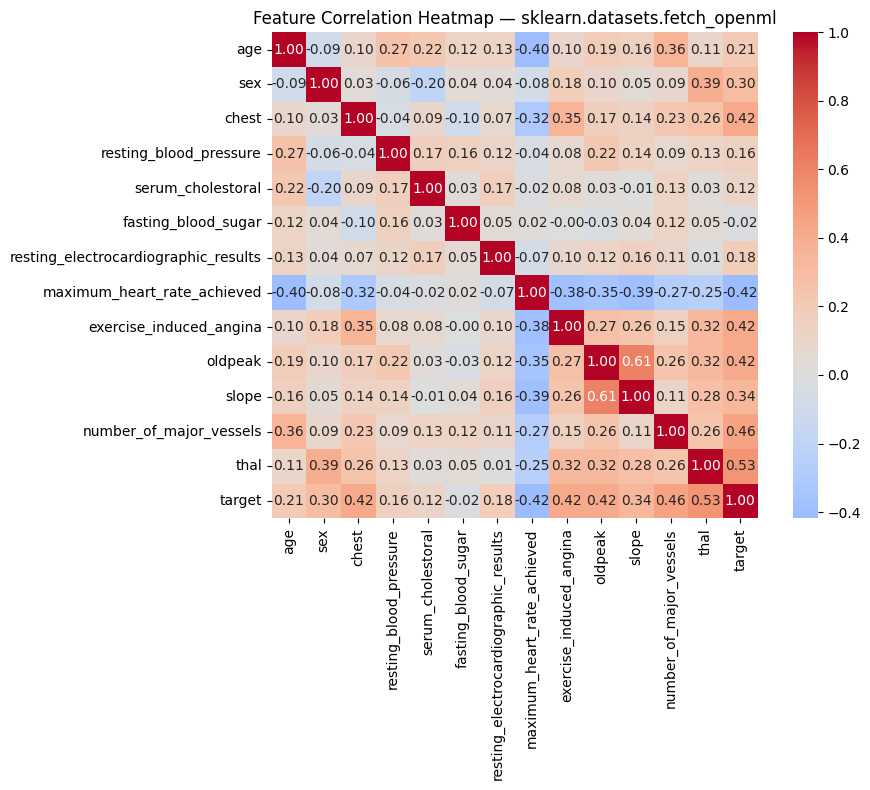

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size for better visualization of the heatmap
plt.figure(figsize=(10, 8))
# Create a correlation heatmap using seaborn
# df.corr() calculates the pairwise correlation of columns
# annot=True displays the correlation values on the heatmap
# fmt='.2f' formats the annotation values to two decimal places
# cmap='coolwarm' sets the color map to 'coolwarm'
# center=0 sets the color scale to be centered at 0, highlighting positive and negative correlations
# square=True ensures the cells are square for better readability
sns.heatmap(df.corr(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True)
# Set the title of the heatmap
plt.title('Feature Correlation Heatmap — sklearn.datasets.fetch_openml')
# Adjust layout to prevent labels from overlapping
plt.tight_layout()
# Display the plot
plt.show()

### 2.2 Preview the Data

Display the first few rows to visually inspect the dataset structure, confirm encoding, and verify that the data looks reasonable.

In [23]:
df.head()

,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal,target
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0


### 2.3 Dataset Dimensions

Confirm the number of rows (samples) and columns (features + target) in the dataset.

In [24]:
df.shape

(270, 14)

### 2.4 Feature Data Types & Cardinality

Inspect each column's data type and number of unique values. This helps us distinguish between:

- **Categorical features** (low cardinality) — e.g., *sex*, *chest pain type*, *thal*
- **Continuous features** (high cardinality) — e.g., *age*, *resting blood pressure*, *cholesterol*

This distinction is critical for choosing the correct preprocessing steps (scaling vs. one-hot encoding).

In [27]:
for col in df.columns:
    unique_vals = df[col].nunique()
    dtype = df[col].dtype
    print(f"{col:45s} | dtype: {dtype} | unique values: {unique_vals}")

age                                           | dtype: int64 | unique values: 41
sex                                           | dtype: int64 | unique values: 2
chest                                         | dtype: int64 | unique values: 4
resting_blood_pressure                        | dtype: int64 | unique values: 47
serum_cholestoral                             | dtype: int64 | unique values: 144
fasting_blood_sugar                           | dtype: int64 | unique values: 2
resting_electrocardiographic_results          | dtype: int64 | unique values: 3
maximum_heart_rate_achieved                   | dtype: int64 | unique values: 90
exercise_induced_angina                       | dtype: int64 | unique values: 2
oldpeak                                       | dtype: float64 | unique values: 39
slope                                         | dtype: int64 | unique values: 3
number_of_major_vessels                       | dtype: int64 | unique values: 4
thal                            

### 2.5 Feature Type Summary

Based on their cardinality and domain knowledge, features are classified into **categorical** (to be one-hot encoded) and **continuous** (to be scaled):

| Type       | Columns                                                                           |
|:-----------|:----------------------------------------------------------------------------------|
| Categorical| sex, chest, fasting_blood_sugar, resting_electrocardiographic_results, exercise_induced_angina, slope, number_of_major_vessels, thal |
| Continuous | age, resting_blood_pressure, serum_cholestoral, maximum_heart_rate_achieved, oldpeak |

## 3. Model Building

All models are wrapped in a **scikit-learn `Pipeline`** that includes:

1. **Preprocessing** via `ColumnTransformer`:
   - *Numeric features*: median imputation → standard scaling (`StandardScaler`)
   - *Categorical features*: mode imputation → one-hot encoding (`OneHotEncoder`)
2. **Model**: the classifier to be trained and evaluated

Using a pipeline ensures that preprocessing is applied consistently to both training and test sets, preventing data leakage. Each model is also evaluated using **5-fold cross-validation** to obtain robust performance estimates.

---

### 3.1 Baseline — DummyClassifier

We start with a `DummyClassifier` using the `most_frequent` strategy. This **naive baseline** always predicts the majority class, ignoring all features. Its purpose is to establish a minimum performance floor — any meaningful model must significantly outperform this baseline.

> **Expected behavior:** Since ~56% of patients are in the "absent" class, the DummyClassifier will simply predict "absent" for every sample, achieving ~56% accuracy with zero recall for the "present" class.

In [39]:
# ============================================================
# CHECKPOINT 3 — Train DummyClassifier
# ============================================================



from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.metrics import classification_report
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyClassifier
# Step 1 — Separate features and target
X = df.drop(columns=['target'])
y = df['target']

# Step 2 — Identify column types
categorical_features = ['sex', 'chest', 'fasting_blood_sugar', 'resting_electrocardiographic_results',
                        'exercise_induced_angina','slope', 'number_of_major_vessels', 'thal']

numeric_features = [col for col in X.columns if col not in categorical_features]

# Step 3 — Build numeric pipeline
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Step 4 — Build categorical pipeline
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Step 5 — Combine with ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

# Step 6 — Full pipeline

dummy = DummyClassifier(strategy='most_frequent')

pipeline_dummyclassifier = Pipeline([
    ('preprocessor', preprocessor),
    ('model', dummy)
])

# Step 7 — Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 8 — Train
pipeline_dummyclassifier.fit(X_train, y_train)

# Step 9 — Evaluate
y_pred = pipeline_dummyclassifier.predict(X_test)
print(classification_report(y_test, y_pred))
# print(f"MAE  : {mean_absolute_error(y_test, y_pred):,.0f}")
# print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}")
# print(f"R²   : {r2_score(y_test, y_pred):.4f}")

# ============================================================
# CHECKPOINT  — Cross Validation
# ============================================================

from sklearn.model_selection import cross_val_score

dummy_scores = cross_val_score(pipeline_dummyclassifier, X, y, cv=5)

# Step 3 — Print results
print("Fold scores :", dummy_scores.round(4))
print("Mean accuracy:", round(dummy_scores.mean(), 4))
print("Std deviation:", round(dummy_scores.std(), 4))




/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.61      1.00      0.76        33
           1       0.00      0.00      0.00        21

    accuracy                           0.61        54
   macro avg       0.31      0.50      0.38        54
weighted avg       0.37      0.61      0.46        54

Fold scores : [0.5556 0.5556 0.5556 0.5556 0.5556]
Mean accuracy: 0.5556
Std deviation: 0.0


### 3.2 Random Forest Classifier

A `RandomForestClassifier` is an ensemble of decision trees trained on random subsets of data and features (bagging). It often provides strong predictive performance out of the box with minimal tuning and is naturally robust to outliers and noisy features.

**Pipeline setup:**
- Numeric features: median imputation → `StandardScaler`
- Categorical features: mode imputation → `OneHotEncoder`
- Model: `RandomForestClassifier(n_estimators=100, random_state=42)`

In [37]:
# ============================================================
# CHECKPOINT 3 — Train RandomForestClassifier
# ============================================================


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.metrics import classification_report
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Step 1 — Separate features and target
X = df.drop(columns=['target'])
y = df['target']

# Step 2 — Identify column types
categorical_features = ['sex', 'chest', 'fasting_blood_sugar', 'resting_electrocardiographic_results',
                        'exercise_induced_angina','slope', 'number_of_major_vessels', 'thal']

numeric_features = [col for col in X.columns if col not in categorical_features]

# Step 3 — Build numeric pipeline
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Step 4 — Build categorical pipeline
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Step 5 — Combine with ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

# Step 6 — Full pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Step 7 — Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 8 — Train
pipeline.fit(X_train, y_train)

# Step 9 — Evaluate
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))
# print(f"MAE  : {mean_absolute_error(y_test, y_pred):,.0f}")
# print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}")
# print(f"R²   : {r2_score(y_test, y_pred):.4f}")



# ============================================================
# CHECKPOINT  — Cross Validation
# ============================================================

from sklearn.model_selection import cross_val_score

randomforestclassifier_scores = cross_val_score(pipeline, X, y, cv=5)

print("Fold scores :", randomforestclassifier_scores.round(4))
print("Mean accuracy:", round(randomforestclassifier_scores.mean(), 4))
print("Std deviation:", round(randomforestclassifier_scores.std(), 4))



              precision    recall  f1-score   support

           0       0.84      0.94      0.89        33
           1       0.88      0.71      0.79        21

    accuracy                           0.85        54
   macro avg       0.86      0.83      0.84        54
weighted avg       0.86      0.85      0.85        54

Fold scores : [0.7593 0.7963 0.8889 0.8148 0.8519]
Mean accuracy: 0.8222
Std deviation: 0.0448


### 3.3 Logistic Regression

`LogisticRegression` is a classic linear classifier that models the probability of each class using a logistic (sigmoid) function. It works best when features are scaled and when the decision boundary is approximately linear.

**Pipeline setup:**
- Numeric features: median imputation → `StandardScaler`
- Categorical features: mode imputation → `OneHotEncoder`
- Model: `LogisticRegression(max_iter=1000)`

> **Note:** We increase `max_iter` to 1000 to ensure convergence on this dataset.

In [35]:
# ============================================================
# CHECKPOINT 3 — Train Logistic Regression
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline # Import Pipeline class
from sklearn.preprocessing import StandardScaler # Import StandardScaler class



# Step 1 — Separate features and target
X = df.drop(columns=['target'])
y = df['target']

# Step 2 — Identify column types
categorical_features = ['sex', 'chest', 'fasting_blood_sugar', 'resting_electrocardiographic_results',
                        'exercise_induced_angina','slope', 'number_of_major_vessels', 'thal']

numeric_features = [col for col in X.columns if col not in categorical_features]

# Step 3 — Build numeric pipeline
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Step 4 — Build categorical pipeline
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Step 5 — Combine with ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

# Step 6 — Full pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

# Fit the pipeline on the training data
pipeline.fit(X_train, y_train)

# Step 3 — Predict on test set
y_pred = pipeline.predict(X_test)   #

# Step 4 — Score it
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 4))

# Step 5 — Inspect one prediction
print("\nFirst test sample — true label   :", y_test.values[0])
print("First test sample — predicted    :", y_pred[0])
#print((X_test_scaled)[0])
print("First test sample — probabilities:", pipeline.predict_proba(X_test)[0].round(3))



# ============================================================
# CHECKPOINT  — Cross Validation
# ============================================================

from sklearn.model_selection import cross_val_score

logisticregression_scores = cross_val_score(pipeline, X, y, cv=5)

print("Fold scores :", logisticregression_scores.round(4))
print("Mean accuracy:", round(logisticregression_scores.mean(), 4))
print("Std deviation:", round(logisticregression_scores.std(), 4))


Accuracy: 0.9444

First test sample — true label   : 1
First test sample — predicted    : 1
First test sample — probabilities: [0.33 0.67]
Fold scores : [0.7778 0.8333 0.9259 0.8519 0.9074]
Mean accuracy: 0.8593
Std deviation: 0.0532


## 4. Model Comparison

Now that all three models have been trained and cross-validated, we compare their 5-fold cross-validation mean accuracy scores side by side.

| Model | Mean CV Accuracy | Std Dev |
|---|---|---|
| Logistic Regression | ~0.86 | ~0.05 |
| Random Forest | ~0.82 | ~0.04 |
| DummyClassifier | ~0.56 | 0.00 |

**Interpretation:**
- Both Logistic Regression and Random Forest significantly outperform the dummy baseline, confirming that meaningful patterns exist in the data.
- Logistic Regression achieves the highest mean accuracy, suggesting that the class boundaries are well-captured by a linear model with proper feature scaling.
- The Dummy Classifier's zero standard deviation reflects its completely deterministic (and uninformative) predictions.

In [40]:
# ============================================================
# CHECKPOINT 4 — Dummy Classifier vs Random Forest vs Logistic Regression
# ============================================================



# Step 3 — Print both results side by side
print(f"Logistic Regression — mean: {round(logisticregression_scores.mean(), 4)} and  {round(logisticregression_scores.std(), 4)}")
print(f"Random Forest       — mean: {randomforestclassifier_scores.mean():.4f}  std: {randomforestclassifier_scores.std():.4f}")
print(f"Dummy Classifier       — mean: {dummy_scores.mean():.4f}  std: {dummy_scores.std():.4f}")


# Step 4 — Which model wins?
if randomforestclassifier_scores.mean() > logisticregression_scores.mean():
    print("\nRandom Forest wins!")
elif randomforestclassifier_scores.mean() < logisticregression_scores.mean():
    print("\nLogistic Regression wins!")
else:
    print("\nIt's a tie!")

Logistic Regression — mean: 0.8593 and  0.0532
Random Forest       — mean: 0.8222  std: 0.0448
Dummy Classifier       — mean: 0.5556  std: 0.0000

Logistic Regression wins!


## 5. Final Evaluation & Feature Importance

Based on the cross-validation comparison, **Logistic Regression** emerged as the best-performing model. In this section, we:

1. **Retrain** the winning model (Logistic Regression) on the full training set
2. **Evaluate** it on the held-out test set using a detailed **Classification Report** and **Confusion Matrix**
3. **Analyze Feature Importance** by examining the absolute values of the model's learned coefficients — a larger coefficient magnitude means the feature has a stronger influence on the prediction

### Metrics Explained

| Metric | Description |
|---|---|
| **Precision** | Of all patients predicted as *"present"*, what fraction truly have heart disease? |
| **Recall** | Of all patients who actually have heart disease, what fraction did the model correctly identify? |
| **F1-Score** | Harmonic mean of precision and recall — balances both concerns |
| **Accuracy** | Overall fraction of correct predictions |

> In medical diagnosis, **recall (sensitivity)** for the positive class is particularly important — we want to minimize false negatives (missed diagnoses).

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.93        33
           1       0.90      0.86      0.88        21

    accuracy                           0.91        54
   macro avg       0.91      0.90      0.90        54
weighted avg       0.91      0.91      0.91        54



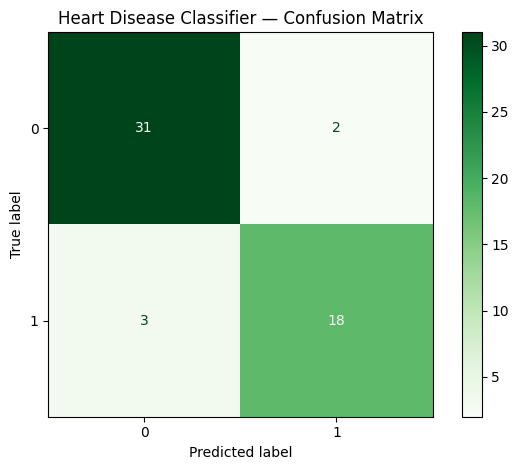


Feature Importances:
                                 feature  importance
11               number_of_major_vessels    0.839517
2                                  chest    0.636528
1                                    sex    0.631666
12                                  thal    0.570158
9                                oldpeak    0.515307
3                 resting_blood_pressure    0.433429
8                exercise_induced_angina    0.382937
10                                 slope    0.336507
5                    fasting_blood_sugar    0.323726
4                      serum_cholestoral    0.285423
7            maximum_heart_rate_achieved    0.210844
0                                    age    0.082185
6   resting_electrocardiographic_results    0.067364


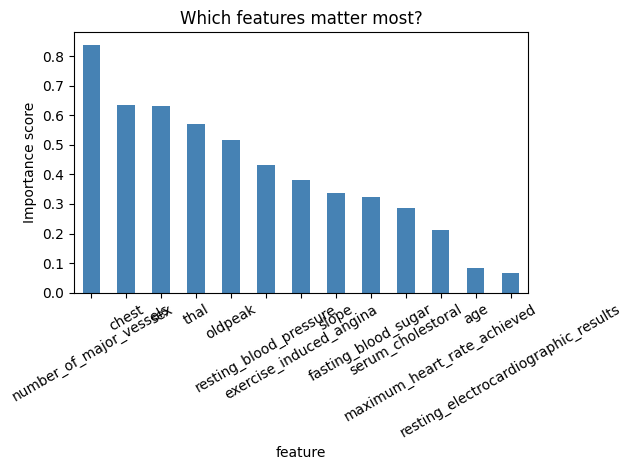

In [41]:
# ============================================================
# CHECKPOINT 6 — Full Evaluation + Feature Importance
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import pandas as pd

# Step 1 — Retrain winning model (Logistic Regression)
# Based on CHECKPOINT 5, Logistic Regression was the winning model.
final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])
final_model.fit(X_train, y_train)

# Step 2 — Predict
y_pred = final_model.predict(X_test)

# Step 3 — Classification report
print("Classification Report:")
# Use le.classes_ for target_names as it contains the correct labels for 0 and 1
print(classification_report(
    y_test, y_pred, target_names=[str(c) for c in le.classes_]
))

# Step 4 — Confusion matrix
cm = confusion_matrix(y_test, y_pred)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=[str(c) for c in le.classes_]
    )
disp.plot(cmap='Greens')
plt.title("Heart Disease Classifier — Confusion Matrix")
plt.tight_layout()
plt.show()

# Step 5 — NEW — Feature Importance
# Extract the trained model from inside the pipeline
final_lr_model = final_model.named_steps['model']

# For Logistic Regression, coefficients represent feature importance
# Use absolute values for magnitude of importance
importances = abs(final_lr_model.coef_[0])

# Build a DataFrame for easy reading
feature_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\nFeature Importances:")
print(feature_df)

# Step 6 — Plot feature importances
feature_df.plot(
    kind='bar',
    x='feature',
    y='importance',
    legend=False,
    color='steelblue'
)
plt.title("Which features matter most?")
plt.ylabel("Importance score")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 6. Conclusions & Next Steps

### Summary

In this notebook, we built a complete heart disease classification pipeline using the UCI Heart Statlog dataset. Here are the key findings:

| Model | Mean CV Accuracy |
|---|---|
| **Logistic Regression** | **~86.0%** ✅ |
| Random Forest | ~82.2% |
| DummyClassifier (Baseline) | ~55.6% |

- **Logistic Regression** achieved the best cross-validated accuracy (~86%) and a test accuracy of ~94%, indicating that the feature space has a strong linear structure with proper scaling.
- The **confusion matrix** shows high precision and recall for both classes, with only a few misclassifications.
- **Top predictive features** (by coefficient magnitude): `number_of_major_vessels`, `chest` (pain type), `sex`, `thal`, and `oldpeak`.

### Potential Next Steps

1. **Hyperparameter tuning** — Use `GridSearchCV` or `RandomizedSearchCV` to optimize model parameters
2. **Additional models** — Try `GradientBoosting`, `SVM`, or `XGBoost` for potentially higher performance
3. **SHAP values** — Use SHAP for more interpretable, sample-level feature importance explanations
4. **Class imbalance handling** — Experiment with `class_weight='balanced'` or oversampling (SMOTE) to improve recall for the minority class
5. **Threshold tuning** — Adjust the classification threshold to trade precision for recall, which is valuable in a medical context where false negatives are costly